In [15]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance as mpf # k线图
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['axes.unicode_minus'] = False

### 创建你的第一个量化策略
1. 参数设置：ticker 数据获取与标准化
2. 参数设置：captical, commission, benchmark
3. 策略与运行：indicators, signals
4. 策略与运行：cross-order, limit, pos, 涨跌停
5. 统计与验证：daily result (pnl)
6. 统计与验证：strategy statistics
7. 结果可视化：持仓收益、最大回撤、日盈亏
8. 结果可视化：市场基准（beta）对比

In [16]:
# 全局参数设置（或数据模块）：工商银行为例
ticker = "601398.SS"
benchmark_ticker = "000001.SS"
start_date = "2024-10-20"
end_date = "2025-10-20"

# 策略模块：全局参数
boll_period = 5
boll_k = 1.5

#### 参数设置：ticker 数据获取与标准化
- 数据获取：yf.download(), 定义参数（股票代码、开始日期、结束日期、复权方式）
- 数据清洗：nan值 -> dropna
- 数据预览：整体看下数据

In [17]:
# 函数1：数据获取
def fetcher_data(ticker:str,start_date:str,end_date:str,auto_clean=True) -> pd.DataFrame:
    """ 获取数据 """
    try:
        print("正在获取历史数据：",ticker, start_date, end_date)
        data = yf.download(tickers=ticker,start=start_date,end=end_date,progress=False)
        # yfinance 个性化处理：去除第二行的列名，即ticker值
        data = data.droplevel(level=1,axis=1)
        print("完成数据获取，共有记录（条数）：", len(data))

        if auto_clean:
            clean_data(data)
    
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return pd.DataFrame

# 函数2：数据清洗
def clean_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 清洗数据：缺失值 """
    try:
        count_nan = data.isnull().sum().sum()
        print("当前data共有缺失值（个数）：",count_nan)
        data = data.dropna()
        count_nan = data.isnull().sum().sum()
        print("缺失值处理完毕，当前缺失值（个数）：",count_nan)
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return data

# 函数3：数据预览
def preview_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 按需要的格式预览数据 """
    print("数据预览：",data)

In [18]:
data = fetcher_data(ticker,start_date,end_date)
preview_data(data)

正在获取历史数据： 601398.SS 2024-10-20 2025-10-20
完成数据获取，共有记录（条数）： 242
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
数据预览： Price          Close      High       Low      Open     Volume
Date                                                         
2024-10-21  5.800471  5.922883  5.781638  5.922883  568464907
2024-10-22  5.781639  5.847553  5.753390  5.809888  431271479
2024-10-23  5.781639  5.800471  5.753390  5.781639  306854479
2024-10-24  5.800471  5.838136  5.762805  5.772222  288789477
2024-10-25  5.762806  5.809888  5.743973  5.791055  284528999
...              ...       ...       ...       ...        ...
2025-10-13  7.141019  7.229422  7.101729  7.190132  395738605
2025-10-14  7.366938  7.366938  7.091906  7.131196  693878140
2025-10-15  7.327648  7.406229  7.288358  7.337471  407599319
2025-10-16  7.494632  7.514277  7.298180  7.298180  495623345
2025-10-17  7.484809  7.583035  7.435697  7.494632  408700246

[242 rows x 5 columns]


#### 参数设置：capital, commission, slippage, benchmark
- initial_capital：初始资金，决定能买多少股票，是收益率、仓位计算的基准，回测设置为尽可能大的整数（如100万）
- commission: 交易手续费（佣金 + 税费），总共约为千1，即0.1% -> 0.001
- slippage: 滑点（成交价偏差），实际成交价与理论信号价的偏差，反应市场流动性和成交延迟，回测过程中设置为万5，即0.05% -> 0.0005
- benchmark: 市场基准（beta），使用上证指数 000001.SS

In [19]:
# 全局交易参数设置
trading_config = {
    "initial_capital":1000000,
    "commission":0.001, # a股买入的话是在0.0003，卖出的话 0.0007，通用使用0.001
    "slippage":0.0005
}

In [20]:
benchmark_data = fetcher_data(benchmark_ticker,start_date,end_date)
preview_data(benchmark_data)

正在获取历史数据： 000001.SS 2024-10-20 2025-10-20
完成数据获取，共有记录（条数）： 242
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
数据预览： Price             Close         High          Low         Open  Volume
Date                                                                  
2024-10-21  3268.110107  3300.664062  3239.096924  3276.060059  668200
2024-10-22  3285.866943  3294.960938  3255.137939  3263.822021  574900
2024-10-23  3302.802979  3331.082031  3277.065918  3285.247070  650400
2024-10-24  3280.262939  3292.945068  3266.882080  3287.823975  519800
2024-10-25  3299.699951  3319.356934  3276.129883  3280.761963  595700
...                 ...          ...          ...          ...     ...
2025-10-13  3889.501953  3895.830078  3800.104980  3800.104980  709500
2025-10-14  3865.229004  3918.436035  3851.121094  3910.781982  800800
2025-10-15  3912.208984  3912.291016  3857.666992  3867.535889  645000
2025-10-16  3916.228027  3931.050049  3899.166992  3900.683105  595500
2025-10-17  3839.754883  3921.064941  3

In [21]:
# 函数4：对比投资标的与市场基准的价格曲线
def plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data,auto_normalize=True):
    combined_data = pd.DataFrame({
        ticker: data['Close'],
        benchmark_ticker: benchmark_data['Close']
    })

    # 数据标准化（0~1）：解决价格差异太大导致无法直观对比的问题
    if auto_normalize:
        combined_data = combined_data / combined_data.iloc[0] * 100
        ylable = "相对涨幅（%）"
    else:
        ylable = "收盘价"

    combined_data.plot(figsize=(12,5), linewidth=2)
    plt.title(f"{ticker} vs {benchmark_ticker} 收盘价对比")
    plt.xlabel("日期")
    plt.ylabel(ylable)
    plt.grid(alpha=0.3)

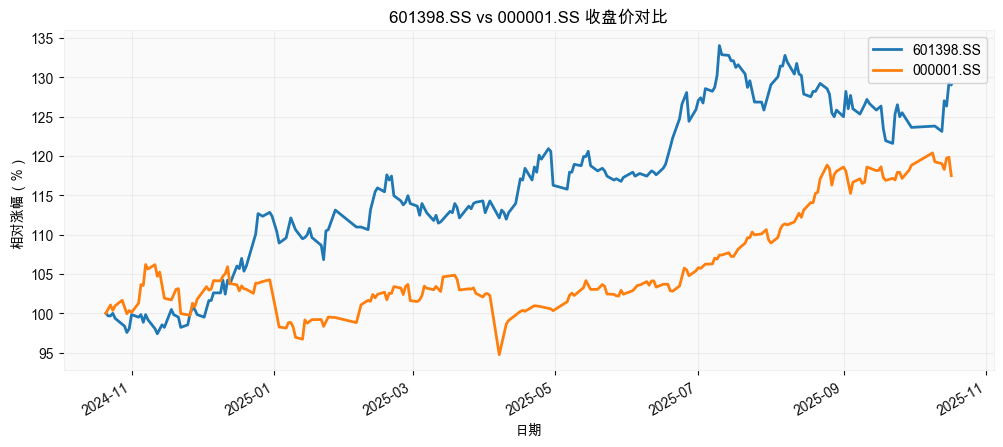

In [22]:
plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data)

#### 策略与运行：indicators, signals
- 核心作用: 找到特征/因子 => 建立特征模型（单个因子/多个因子/权重配置）=> 创建策略规则 => 生成交易信号（涉及配对交易的问题）=> 进行后续回测
- 因子概念: 基于此进行量化策略的规则编写，比如：技术指标（KDJ-动量因子、MA-趋势因子）、基本面指标（PE-价值因子）
- 代码实现: 单因子（BOLL）=> 价格上穿下轨：买入/做多，价格下穿上轨：卖出/平仓/做空
- 函数创建: def calculate_boll（因子指标模块）、def generate_signals（因子指标/策略模块）、def plot_signals（可视化信号-验证计算）

In [23]:
# 函数4：def calculate_boll（因子指标模块）
def calculate_boll(data:pd.DataFrame,period:int,std_k:int) -> pd.DataFrame:
    """ 计算Boll布林带指标
        - 中轨：n日移动均线
        - 上轨：n日移动均线 + k * n日收盘价std
        - 下轨：n日移动均线 - k * n日收盘价std
    """
    try:
        data['BOLL_MA'] = data['Close'].rolling(window=period).mean()
        data['BOLL_STD'] = data['Close'].rolling(window=period).std()
        data['BOLL_UP'] = data['BOLL_MA'] + std_k * data['BOLL_STD']
        data['BOLL_DN'] = data['BOLL_MA'] - std_k * data['BOLL_STD']
        print(f"已完成指标计算：BOLL, 周期-{period}, 标准差倍数-{std_k}")
        return data
    except Exception as e:
        print("BOLL计算异常：",e)
        return pd.DataFrame

# 函数5：def generate_signals（因子指标/策略模块）
def generate_signals(data:pd.DataFrame) -> pd.DataFrame:
    """ 通用模块：参数化设置实现多因子信号的生成，也是核心需要修改的策略规则逻辑 """
    try:
        data['Signal'] = 0
        
        # 以下内容为信号生成逻辑，可以自定义，核心是获取 Signal 列的值（1买入 -1卖出）
        
        # 单因子（BOLL）=> 价格上穿下轨：买入/做多，价格下穿上轨：卖出/平仓/做空
        prev_price = data['Close'].shift(1)
        buy_condition = (prev_price<=data['BOLL_DN']) & (data['Close']>=data['BOLL_DN'])
        sell_condition = (prev_price>=data['BOLL_UP']) & (data['Close']<=data['BOLL_UP'])

        data.loc[buy_condition,'Signal'] = 1
        data.loc[sell_condition,'Signal'] = -1
        print(f"已完成信号生成：BOLL，买入信号次数：{buy_condition.sum()}，卖出信号次数：{sell_condition.sum()}")
        return data
    except Exception as e:
        print("信号生成异常：",e)
        return pd.DataFrame
        

# 函数6：def plot_signals（可视化信号-验证计算）
def plot_signals(data:pd.DataFrame,title:str):
    """ 绘制指标与信号 """

    # 定义子图：布林带上中下轨、买入卖出信号
    buy_signal = np.where(data['Signal']==1,data['Close'],np.nan)
    sell_signal = np.where(data['Signal']==-1,data['Close'],np.nan)
    
    subplots = [
        mpf.make_addplot(data['BOLL_MA'],color='blue',linestyle='--',label='Middle'),
        mpf.make_addplot(data['BOLL_UP'],color='red',linestyle='--',label='Upper'),
        mpf.make_addplot(data['BOLL_DN'],color='green',linestyle='--',label='Lower'),
        mpf.make_addplot(buy_signal, type='scatter', marker='^', markersize=100, color='red',label='Buy'),
        mpf.make_addplot(sell_signal, type='scatter', marker='v', markersize=100, color='green',label='Sell')
    ]

    # 绘制
    mpf.plot(
        data,
        type='candle',
        style='yahoo',
        title=title,
        addplot=subplots,
        volume=False,
        figsize=(12,6),
        tight_layout=True,
        xrotation=15,
    )

已完成指标计算：BOLL, 周期-5, 标准差倍数-1.5
已完成信号生成：BOLL，买入信号次数：3，卖出信号次数：5


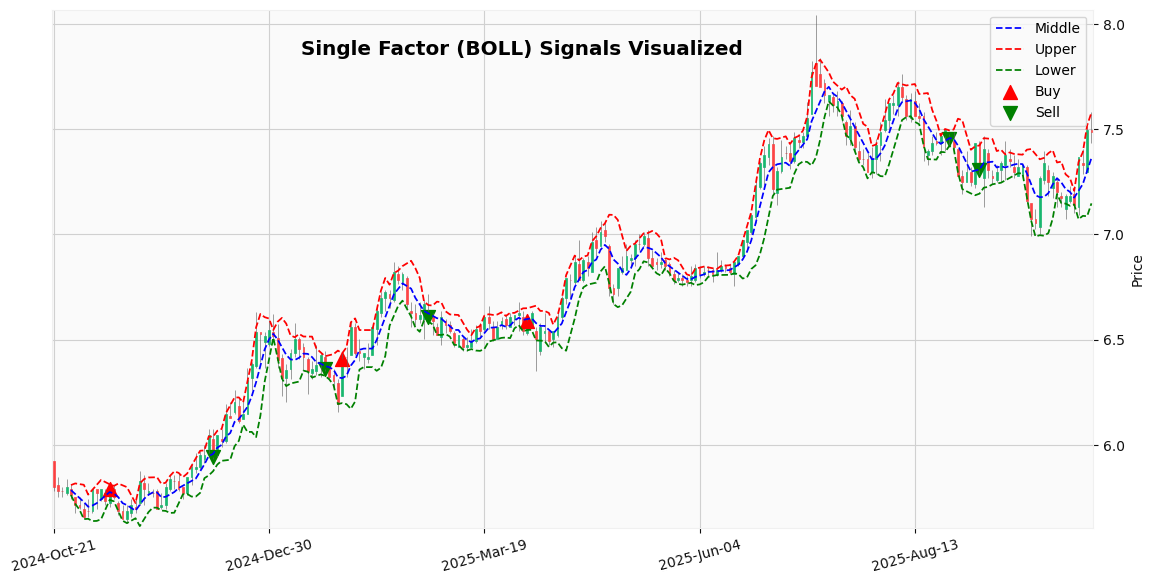

In [24]:
indicators = calculate_boll(data,boll_period,boll_k)
signals = generate_signals(indicators)
plot_signals(signals,"Single Factor (BOLL) Signals Visualized")

#### 策略与运行：cross-order, limit, pos, 涨跌停
- 核心功能：执行买卖交易、存储交易记录、每笔交易（卖出）的盈亏分析（净利润，收益率）
- cross-order 撮合订单：买入价格 >= 卖出价格（卖盘）就会自动撮合，否则就会挂单表示委托状态中
- 委托单类型：market 市价单 => 滑点、limit 限价单 => 无法交易 => limit price ± 0.001%
- 处理涨跌停：前收盘价 > ± 10% 则无法成交
- 函数：def execute_trade => 下订单+存交易记录

In [25]:
# 设置交易信息初始值（全局） => 思考个人账户页面的汇总数据有哪些
trading_state = {
    'cash': trading_config['initial_capital'], # 账户可用资金
    'positions': {}, # 存储投资标的持仓，如：{"000001.SS":10000, "601398.SS":2000}
    'trades': [], # 存放交易记录：price,quantity,date,cost,net_revenue,profit_rate
    'values': [] # 存放每日盈亏数据：position * price -> pos value (+cash)-> total value->今明总值比较->日盈亏
}

In [26]:
# 函数7：def execute_trade => 下订单+存交易记录
def execute_trade(symbol:str, quantity: int, price: float, date: pd.Timestamp, commission: float = trading_config['commission']):
    """
    执行交易：买入、卖出、交易记录；实际的交易接口交互的过程中，交易信息是直接发给券商API => 进行订单委托、更新账户信息 => 得到状态码
    """
    try:
        # 买入
        if quantity > 0:
            # 买入：执行交易 => 是否满足可交易条件：可用资金足够 => 更新持仓信息
            cost = quantity * price * (1+commission)
            if cost <= trading_state['cash']:
                trading_state['cash'] -= cost # 资金流出
                trading_state['positions'][symbol] = trading_state['positions'].get(symbol,0) + quantity # 流入
                # 买入：记录交易 => 汇总信息并添加至 trading_state['trades'] => cost 总成本
                trade_record = {
                    'symbol':symbol,
                    'quantity':quantity,
                    'price':price,
                    'type':'buy',
                    'timestamp':date,
                    'cost':cost,
                    'commission':cost - (quantity * price)
                }
                trading_state['trades'].append(trade_record)

                print(f"➕买入成功！{symbol} +{quantity}股 @{price} 总成本 {cost} 可用资金 {trading_state['cash']}")
            else:
                print(f"❌可用资金不足！总成本 {cost} 可用资金 {trading_state['cash']}")
                
        # 卖出
        else:
            quantity = abs(quantity)
            # 卖出：执行交易 => 是否满足可交易条件：仓位pos足够 => 计算收益 => 更新持仓信息
            if trading_state['positions'].get(symbol,0) >= quantity:
                # 计算净收益
                gross_revenue = quantity * price # 按当前价格和仓位卖出的市值
                commission_cost = gross_revenue * commission # 计算佣金
                net_revenue = gross_revenue - commission_cost # 纯收益

                # 找到买入成本
                buy_cost = get_latest_buy_cost(symbol)
                
                # 计算盈亏 profit and loss 盈亏
                profit_loss = net_revenue - buy_cost # 当前卖出和此前买入的收益/亏损值（差值）
                profit_rate = profit_loss / buy_cost # >0 正收益 <0 负收益
                profit_rate_pct = f"{profit_rate:.2%}"

                # 更新持仓和可用资金
                trading_state['positions'][symbol] -= quantity # 减持，资金流出
                trading_state['cash'] += net_revenue
                
                # 卖出：记录交易 => 汇总信息并添加至 trading_state['trades'] => 净收益 net_revenue, 收益比
                trade_record = {
                    'symbol':symbol,
                    'quantity':quantity,
                    'price':price,
                    'type':'sell',
                    'timestamp':date,
                    'gross_revenue':gross_revenue,
                    'commission':commission_cost,
                    'net_revenue':net_revenue,
                    'buy_cost':buy_cost,
                    'profit_loss':profit_loss,
                    'profit_rate':profit_rate,
                    'profit_rate_pct':profit_rate_pct
                }
                trading_state['trades'].append(trade_record)

                print(f"➖卖出成功！{symbol} -{quantity}股 @{price} 净收益 {net_revenue} 盈亏 {profit_loss} 盈亏比 {profit_rate_pct} 可用资金 {trading_state['cash']}")
            else:
                print(f"❌可用仓位不足！总仓位 {trading_state['positions'].get(symbol,0)}")
                
    except Exception as e:
        print(f"交易异常：{e}")

# 函数8：辅助计算函数，找到最近买入记录对应的总成本
def get_latest_buy_cost(symbol:str) -> float:
    """
    获取指定投资标的的最新买入成本（全进全出策略，即：无加减仓逻辑）
    """
    for trade in reversed(trading_state['trades']):
        if trade['symbol'] == symbol and trade['type'] == 'buy':
            return trade['cost'] 
    print(f"⚠️警告：未找到 {symbol} 的买入记录")
    return 0.0

In [27]:
# execute_trade(ticker, 100000, 6.78, "2025-10-31")
# execute_trade(ticker, -100000, 6.78, "2025-10-31")

# execute_trade(benchmark_ticker, 80000, 4.28, "2025-10-31")
# execute_trade(benchmark_ticker, -80000, 5.76, "2025-10-31")

# trading_state
pd.DataFrame(trading_state['trades'])

""


In [29]:
execute_trade(ticker, 100000, 6.78, "2025-10-31")
execute_trade(ticker, -100000, 6.78, "2025-10-31")


❌可用资金不足！总成本 678677.9999999999 可用资金 321322.0000000001
➖卖出成功！601398.SS -100000股 @6.78 净收益 677322.0 盈亏 -1355.9999999998836 盈亏比 -0.20% 可用资金 998644.0000000001
